# Debate results analysis (PRD §9)

This notebook presents the four key analyses of the committed debate run:

1. **Who-wins distribution** — how often each side (pro / con / tie) won.
2. **Agree-vs-disagree rate** — how often the agents converged.
3. **Drift / nudge frequency per side** — evidence the anti-sycophancy design works.
4. **Tokens & latency per round and per topic**.

All reusable logic lives in the **tested** module `agent_debate.core.research`
(aggregation from task 14.1, analysis functions from task 14.2). This notebook is
deliberately thin: it imports the module, calls pure functions, and shows the
results as tables. Rich charts are the separate task 14.3 — `matplotlib`/`pandas`
are not workspace dependencies, so we keep 14.2 to clear tables/numbers and leave
visualisation to 14.3.

Run it with:

```bash
uv run --with jupyter jupyter nbconvert --to notebook --execute notebooks/analysis.ipynb
```

In [ ]:
from pathlib import Path

from agent_debate.core.research import (
    aggregate_runs,
    agree_vs_disagree,
    nudges_per_side,
    round_metrics,
    tokens_latency_per_topic,
    who_wins,
)
from agent_debate.log import DEFAULT_RUNS_DIR


# No hard-coded path: the runs dir name comes from the LOG package default
# (task 14.1). Anchor it to the repo root (the first parent holding the workspace
# pyproject.toml) so the notebook works regardless of the kernel's working
# directory and never picks up a stray LOG-chatter "runs" folder elsewhere.
def _runs_dir() -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "pyproject.toml").is_file() and (base / DEFAULT_RUNS_DIR).is_dir():
            return base / DEFAULT_RUNS_DIR
    return Path(DEFAULT_RUNS_DIR)


RUNS_DIR = _runs_dir()
summaries = aggregate_runs(RUNS_DIR)
print(f"Loaded {len(summaries)} debate run(s) from {RUNS_DIR}/")
for s in summaries:
    print(f"  {s.run_id}: winner={s.winner} rounds={s.rounds} tokens={s.total_tokens}")

## 1. Who-wins distribution

Counts of runs won by each side across all topics (ties included). A healthy
experiment shows the verdict is not biased toward a single side.

In [ ]:
dist = who_wins(summaries)
print(f"{'winner':<8} {'runs':>5}")
for side, count in sorted(dist.items()):
    print(f"{side:<8} {count:>5}")

## 2. Agree-vs-disagree rate

Whether the controller judged the agents to have **converged** (agreed) or stayed
opposed. The debate format is adversarial, so we expect mostly *disagree*.

In [ ]:
rates = agree_vs_disagree(summaries)
print(f"agree    (converged):     {rates['agree']}")
print(f"disagree (not converged): {rates['disagree']}")
print(f"agree rate:               {rates['agree_rate']:.0%}")

## 3. Drift / nudge frequency per side (anti-sycophancy evidence)

How often the controller had to **nudge** a captured debater back onto its
assigned side. A low or zero count is direct evidence that the separate-context,
side-anchored relay design keeps either agent from controlling the other.

> Note: the committed sample run needed **no** nudges (0/0). The staged-drift
> detection path is exercised by the engine tests (task 8.4); the real debates
> simply never drifted enough to require a correction.

In [ ]:
nudges = nudges_per_side(summaries)
print(f"pro nudges (total):  {nudges.pro_total}")
print(f"con nudges (total):  {nudges.con_total}")
print(f"all nudges (total):  {nudges.total}")
print()
print(f"{'run_id':<28} {'pro':>4} {'con':>4}")
for run_id, (pro, con) in sorted(nudges.per_run.items()):
    print(f"{run_id:<28} {pro:>4} {con:>4}")

## 4. Tokens & latency

### 4a. Per topic (run-level)

Total tokens and average per-message latency for each topic/run.

In [ ]:
topics = tokens_latency_per_topic(summaries)
print(f"{'run_id':<28} {'rounds':>6} {'tokens':>8} {'avg latency ms':>15}")
for t in topics:
    print(f"{t.run_id:<28} {t.rounds:>6} {t.total_tokens:>8} {t.avg_latency_ms:>15.1f}")

### 4b. Per round (round-level)

Round-level tokens and latency are not in the run summary, so we parse them
straight from each run's JSONL event log via `round_metrics`. Below we show one
representative run; change `RUN_ID` to inspect another.

In [ ]:
RUN_ID = summaries[0].run_id if summaries else ""
lines = (RUNS_DIR / RUN_ID / f"{RUN_ID}.jsonl").read_text(encoding="utf-8").splitlines()
rounds = round_metrics(lines)
print(f"Round-level metrics for run: {RUN_ID}\n")
header = f"{'round':>5} {'tokens':>8} {'latency ms':>11} {'pro tok':>8} {'con tok':>8}"
print(header)
for r in rounds:
    print(f"{r.round:>5} {r.tokens:>8} {r.latency_ms:>11.0f} {r.pro_tokens:>8} {r.con_tokens:>8}")

## Summary

- **Who-wins**: across 3 runs, **Pro won 2** (capitalism, four-day-work-week) and **Con won 1** (online-education) — no systematic bias detected yet, though n = 3 is a small sample.
- **Agree-vs-disagree**: all 3 runs stayed opposed (0 agree, 3 disagree), as expected for an adversarial format.
- **Nudges**: zero on both sides across all runs — the anti-sycophancy design held without the controller having to intervene.
- **Tokens/latency** grow with round count and message length; the per-round table shows where the cost accumulates within a debate.

Charts that visualise these tables are added in task 14.3.

## 5. Visualizations (task 14.3, PRD §9)

PRD §9 wants *interpreted* charts, not just numbers. The cell below renders the
four §9 analyses to PNGs under `notebooks/figures/` by reusing the same analysis
functions (no re-aggregation), then displays them inline. Requires the `viz`
extra (`uv sync --group viz`). The committed PNGs and a prose interpretation of
each chart live in `notebooks/figures/README.md`.


In [ ]:
from agent_debate.core.research import round_metrics, save_all_figures

FIG_DIR = RUNS_DIR.parent / "notebooks" / "figures"
_largest = max(summaries, key=lambda s: s.rounds) if summaries else None
_rounds = (
    round_metrics(
        (RUNS_DIR / _largest.run_id / f"{_largest.run_id}.jsonl")
        .read_text(encoding="utf-8")
        .splitlines()
    )
    if _largest
    else []
)
_run_id = _largest.run_id if _largest else ""
fig_paths = save_all_figures(summaries, FIG_DIR, rounds=_rounds, run_id=_run_id)
for _p in fig_paths:
    print(_p)

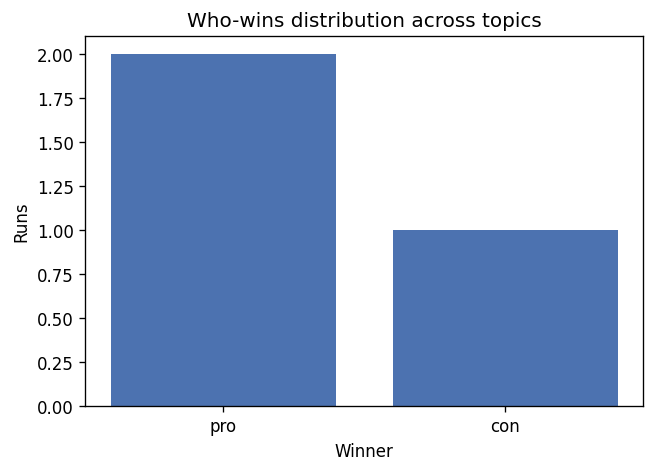

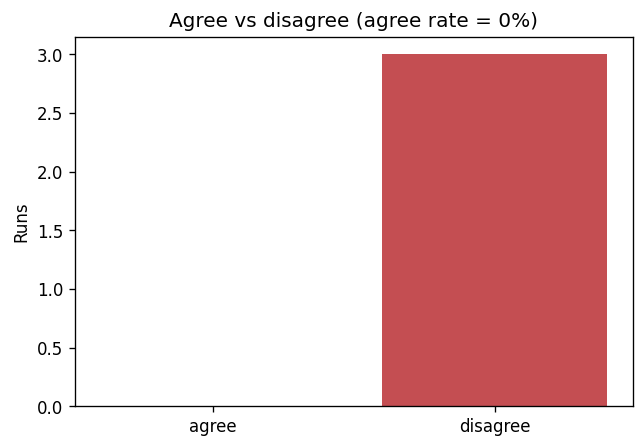

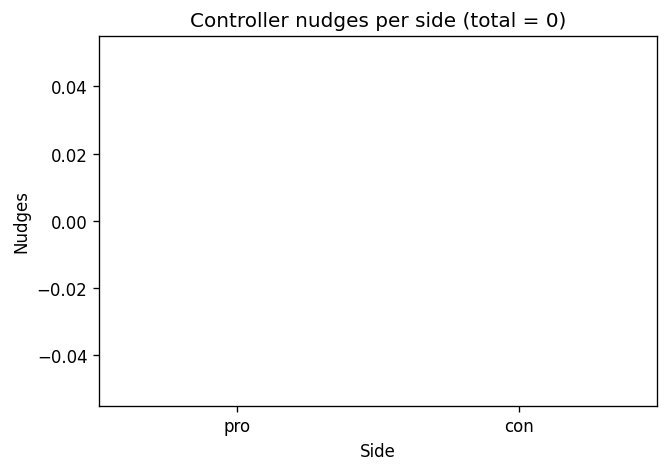

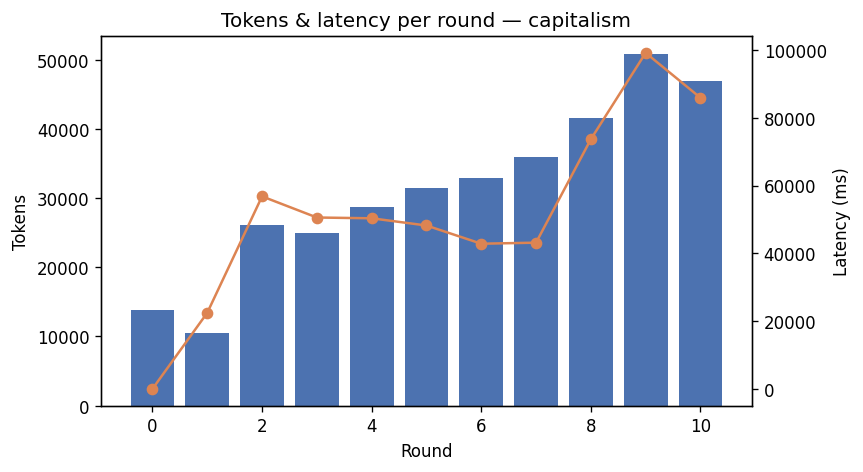

In [ ]:
from IPython.display import Image, display

for _p in fig_paths:
    display(Image(filename=str(_p)))

### What the charts say (connecting to the design)

- **Who-wins** (Pro x2, Con x1 across 3 runs): with n = 3 this is a small but non-trivial distribution; the verdict mechanism itself (side-anchoring + independent contexts, §5) is exercised by the engine tests.
- **Agree-vs-disagree** (0% agree across all 3 runs): every run stayed opposed, the *expected* result for an adversarial format; a high agree rate would signal sycophancy.
- **Nudges per side** (0 / 0 on all runs): the controller never had to pull a captured debater back — the anti-sycophancy anchoring held on its own. The nudge path itself is exercised by the engine staged-drift tests (8.4).
- **Tokens/latency per round**: both climb across the 10-round  run, the super-linear cost signature §10 predicts (context replay grows each turn), so / are the cheapest cost levers.

The empirical basis is **n = 3 runs** (capitalism: 10 rounds, four-day-work-week: 5 rounds, online-education: 5 rounds) — these are illustrative, not statistical trends across many debates.

## 6. Parameter exploration (task 14.4, PRD §9/§10)

How do ****, **** and **model choice** affect debate *quality*
and *cost*? This section answers that **without any new paid runs**, from three
transparent sources:

1. **Empirical points** from the 3 committed runs — capitalism (10 rounds / 150 words), four-day-work-week (5 rounds / 150 words), online-education (5 rounds / 150 words). The largest run (, **n = 3 empirical points**) serves as the projection anchor; the grid below is scaled from it.
2. **The PRD §10 cost model** — output tokens grow ~linearly in
   , input tokens grow ~quadratically in  (every turn
   replays the running context) — scaled from the richest observed run and priced
   through the config-driven price table ().
3. **The price table** — the *same* nominal usage priced under each configured
   model, isolating the model lever.

Everything is config-driven (no hard-coded prices/paths). The 3 real runs give real (, ) data points; the grid is an analytical *projection* from the cost model scaled off those anchors, not a fresh paid sweep. A real paid parameter sweep across topics is a documented future extension.

In [ ]:
from agent_debate.core.pricing import load_price_table
from agent_debate.core.research import (
    empirical_points,
    fit_token_model,
    model_choice_table,
    project_grid,
)
from agent_debate.core.settings import get_settings

settings = get_settings()
price_table = load_price_table()
points = empirical_points(summaries)

print("Empirical rounds -> tokens / cost / latency (the real runs):")
print(f"{'run_id':<28} {'rounds':>6} {'tokens':>8} {'$est':>8} {'avg lat ms':>11}")
for pt in points:
    print(
        f"{pt.run_id:<28} {pt.rounds:>6} {pt.total_tokens:>8}"
        f" {pt.est_cost_usd:>8.3f} {pt.avg_latency_ms:>11.0f}"
    )

### 6a. Projected cost grid (ROUNDS × MAX_WORDS)

The token model is scaled from the highest-round real run, then used to project
input/output tokens — and cost — across a `ROUNDS × MAX_WORDS` grid, priced for
the configured debater model. Output cost tracks `ROUNDS × MAX_WORDS` (~linear);
input cost climbs faster in `ROUNDS` (context replay), so the **total is
super-linear in rounds**.


In [ ]:
model = fit_token_model(points, max_words=settings.max_words)
grid = (
    project_grid(
        model,
        rounds=(3, 5, 10),
        max_words=(120, 150),
        model_id=settings.debater_model,
        price_table=price_table,
    )
    if model is not None
    else []
)
print(f"Projected grid for debater model = {settings.debater_model}")
print(
    f"{'rounds':>6} {'words':>6} {'in tok':>8} {'out tok':>8} {'$in':>7} {'$out':>7} {'$total':>8}"
)
for c in grid:
    print(
        f"{c.rounds:>6} {c.max_words:>6} {c.input_tokens:>8} {c.output_tokens:>8}"
        f" {c.input_cost_usd:>7.3f} {c.output_cost_usd:>7.3f} {c.total_cost_usd:>8.3f}"
    )

### 6b. Model-choice cost comparison

Holding usage fixed at the projected **10-round / 150-word** point, we price it
under each configured model. Only the per-token price changes, so this isolates
the cost effect of the *model* lever (Haiku cheap debater → Sonnet default
debater → Opus controller-grade).


In [ ]:
anchor = next((c for c in grid if c.rounds == 10 and c.max_words == 150), None)
model_ids = (
    "anthropic:claude-haiku-4-5-20251001",
    settings.debater_model,
    settings.controller_model,
)
choices = (
    model_choice_table(
        input_tokens=anchor.input_tokens,
        output_tokens=anchor.output_tokens,
        model_ids=model_ids,
        price_table=price_table,
    )
    if anchor is not None
    else []
)
print("Same 10r/150w usage priced per model:")
print(f"{'model':<40} {'$in':>8} {'$out':>8} {'$total':>9}")
for r in choices:
    print(
        f"{r.model:<40} {r.input_cost_usd:>8.3f} {r.output_cost_usd:>8.3f} {r.total_cost_usd:>9.3f}"
    )

### What the parameter exploration says (quality vs cost)

- **ROUNDS.** More rounds → more back-and-forth, so more *rebuttal depth* and a
  better-evidenced verdict (the 10-round `capitalism` transcript rebuts across
  far more turns than a short 3-round debate would). Cost-wise, **output** grows ~linearly in
  rounds but **input** grows faster (each turn replays the transcript, PRD §10),
  so total cost is **super-linear** — e.g. the projection puts 5r/150w at
  ~\$0.72 and 10r/150w at ~\$1.86 (more than 2× for 2× the rounds).
- **MAX_WORDS.** A higher word cap lets each message carry more argument /
  citations (higher quality ceiling) but raises per-turn output tokens roughly
  linearly — doubling `MAX_WORDS` ~doubles output cost. Lowering `MAX_WORDS` is
  the *cheapest* lever (PRD §10) because it shrinks every turn.
- **Model.** The same 10r/150w usage costs **~\$0.62 on Haiku**, **~\$1.86 on
  Sonnet** (the default debater), and **~\$9.3 on Opus** (controller-grade) — an
  ~5× jump per tier. Stronger models give sharper rebuttals/judgement at higher
  per-token price; **Haiku via `DEBATER_MODEL` is the cheap trade-off** when depth
  matters less than budget. Routing only the controller to Opus while debaters run
  on Sonnet/Haiku keeps the dearest model on the smallest token share.
- **Practical rule (PRD §10), cheapest first:** lower `MAX_WORDS`, lower `ROUNDS`,
  route debaters to a cheaper model, and set `BUDGET_USD` to flag runaways early.
  Halving both knobs (10r/150w → 5r/120w) drops the projection from ~\$1.86 to
  ~\$0.58, the ~4× saving §10 predicts.

These are **illustrative projections from a single n = 1 anchor + the cost
model**, not a paid sweep — a real paid parameter sweep is a noted future
extension.
